In [1]:
import numpy as np
import pandas as pd
import sys
import os
sys.path.append(os.path.abspath('../../..'))
import matplotlib.pyplot as plt
from scripts import nodes as n
from scripts import elements as e
from scripts import material_params as mat
from scipy.linalg import eigh
import plotly.graph_objects as go

In [2]:
nodes = []
nodal_values = np.loadtxt('../../../text_files/nodes_minimal_model_.txt', delimiter=',')
for i in range(nodal_values.shape[0]):
  nodes.append(n.nodes(nodal_values[i, 0], nodal_values[i, 1], nodal_values[i, 2]))

In [3]:
# Truss parameters
E = 210e9  # Young's modulus in Pascals
nu = 0.3   # Poisson's ratio
G = E / (2 * (1 + nu))  # Shear modulus in Pascals
m = 5596024 #kg
d1 = 0.8 #m
d2 = 1.8 #m
t1 = 0.03 #m
t2 = 0.08 #m
L_truss_element_y = 15 #m
h_truss = 18 #m
Aeq, Ieqy, Ieqz, b_eq, h_eq = mat.effective_truss_stiffness(d1, d2, t1, t2, h_truss, L_truss_element_y) 
L = 237.5
rho_truss = m / (L * Aeq)
It = (b_eq * h_eq**3 / 3) * (1 - 0.63 * (h_eq / b_eq) * (1 - (h_eq**4 / (12 * b_eq**4)))) *0.06
k = 0.08
Ip  = Ieqy + Ieqz
ep_K = [E, G, Aeq, Ieqy, Ieqz, It, k]
ep_m = [rho_truss, Aeq, Ieqy, Ieqz, Ip]


d_out = 1.8 
d_in = 1.8  - (2 * 80) / 1000

def stiffness_connecting_beams(d_out, d_in):
    # Connecting beams parameters

    h = 18

    A = 2 * np.pi * (d_out/2)**2 - np.pi * (d_in/2)**2
    Iy = 2 * ( (np.pi / 4) * ((d_out/2)**4 - (d_in/2)**4) + A * (h/2)**2) 
    Iz = 2 * ( (np.pi / 4) * ((d_out/2)**4 - (d_in/2)**4) )
    Ip = Iy + Iz    
    It = Ip 
    

    return Iy, Iz, Ip, It, A

k = 5/6
rho = 7850 #kg/m^3
E=210e9 #Pa
G = E/(2*(1+nu)) #Pa
nu = 0.3 #Poisson's ratio
k_fender = mat.stiffness_fenders()
Iy_connect, Iz_connect, Ip_connect, It_connect, A_connect = stiffness_connecting_beams(d_out, d_in)
ep_K_connect = [E, G, A_connect, Iy_connect, Iz_connect, It_connect, k]
ep_m_connect = [rho, A_connect, Iy_connect, Iz_connect, Ip_connect]


E = 210e9 #Pa
# Material parameters retaining wall
t_eff = 1#m
A_eq_wall, I_eqy_wall, I_eqz_wall, b_eq_wall, rho_wall = mat.effective_retaining_wall_stiffness(t_eff)
Ip_wall = I_eqy_wall + I_eqz_wall
It_wall = (b_eq_wall * t_eff**3 / 3) * (1 - 0.63 * (b_eq_wall / t_eff) + 0.052 * (b_eq_wall / t_eff) **5)

I_eqy_wall = 1e7
I_eqz_wall = 1e7
Ip_wall = I_eqy_wall + I_eqz_wall
It_wall  = 1e7


ep_K_wall = [E, G, A_eq_wall, I_eqy_wall, I_eqz_wall, It_wall, k]
ep_m_wall = [rho_wall, A_eq_wall, I_eqy_wall, I_eqz_wall, Ip_wall]
print(rho_wall)

print(mat.effective_retaining_wall_stiffness(t_eff))
print(mat.effective_truss_stiffness(d1, d2, t1, t2, L_truss_element_y, h_truss))
print(stiffness_connecting_beams(d_out, d_in))

458.02196474590005
(68, 4196.196078431372, 1362.1960784313726, 3.090909090909091, 458.02196474590005)
(3.17049530600282, 301.6, 256.36, 7.297687177237888, 7.91545310187776)
(482.5900664338916, 0.32040827013808765, 482.9104747040297, 482.9104747040297, 2.976973198541688)


Loop  0 completed d_in =  1.6
Loop  1 completed d_in =  1.60178
Loop  2 completed d_in =  1.6035599999999999
Loop  3 completed d_in =  1.6053399999999998
Loop  4 completed d_in =  1.6071199999999997
Loop  5 completed d_in =  1.6088999999999996
Loop  6 completed d_in =  1.6106799999999994
Loop  7 completed d_in =  1.6124599999999993
Loop  8 completed d_in =  1.6142399999999992
Loop  9 completed d_in =  1.6160199999999991
Loop  10 completed d_in =  1.617799999999999
Loop  11 completed d_in =  1.619579999999999
Loop  12 completed d_in =  1.6213599999999988
Loop  13 completed d_in =  1.6231399999999987
Loop  14 completed d_in =  1.6249199999999986
Loop  15 completed d_in =  1.6266999999999985
Loop  16 completed d_in =  1.6284799999999984
Loop  17 completed d_in =  1.6302599999999983
Loop  18 completed d_in =  1.6320399999999982
Loop  19 completed d_in =  1.633819999999998
Loop  20 completed d_in =  1.635599999999998
Loop  21 completed d_in =  1.6373799999999978
Loop  22 completed d_in =  1

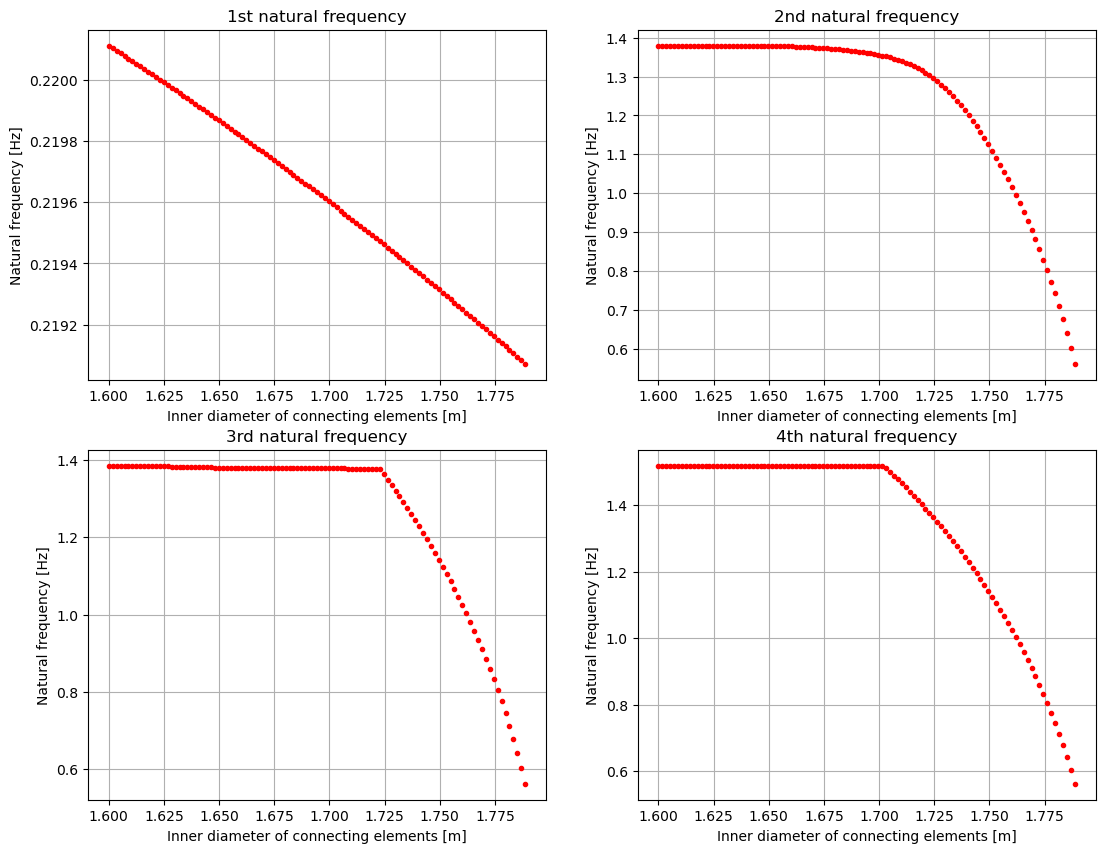

In [4]:
d_out = 1.8
d_in_max = d_out - 0.01
N = 1000
d_in = np.arange(1.6, d_in_max, (d_in_max - 0.01) / N)


fig, axs = plt.subplots(2, 2, figsize=(13, 10))

eig_freqs = []
N = len(nodes)
DOFS_per_node = 6


for i in range(len(d_in)):
    Iy_connect, Iz_connect, Ip_connect, It_connect, A_connect = stiffness_connecting_beams(d_out, d_in[i])
    ep_K_connect = [E, G, A_connect, Iy_connect, Iz_connect, It_connect, k]
    ep_m_connect = [rho, A_connect, Iy_connect, Iz_connect, Ip_connect]

    elements = []
    element_nodes = np.loadtxt('../../../text_files/element_nodes3.txt', dtype=int)
    for ii in range(element_nodes.shape[0]):
        if element_nodes[ii, 2] == 0:
            elements.append(e.elements(nodes[element_nodes[ii, 0] - 1], nodes[element_nodes[ii, 1] - 1], ep_K, ep_m))
        elif element_nodes[ii, 2] == 1:
            elements.append(e.elements(nodes[element_nodes[ii, 0] - 1], nodes[element_nodes[ii, 1] - 1], ep_K_wall, ep_m_wall))
        elif element_nodes[ii, 2] == 2:
            elements.append(e.elements(nodes[element_nodes[ii, 0] - 1], nodes[element_nodes[ii, 1] - 1], ep_K_connect, ep_m_connect))

    element_nodes = np.loadtxt('../../../text_files/element_nodes.txt', dtype=int)


    dofs = n.degrees_of_freedom(nodes)

    element_locs = []

    for (nA, nB) in element_nodes:
        dofs_A = dofs[f'dof_{nA}']
        dofs_B = dofs[f'dof_{nB}']
        element_locs.append(np.hstack((dofs_A, dofs_B)))



    K_global = np.zeros((N * DOFS_per_node, N * DOFS_per_node))
    M_global = np.zeros((N * DOFS_per_node, N * DOFS_per_node))

    K_locs = []
    M_locs = []



    for j in range(len(element_locs)):
        K_global[np.ix_(element_locs[j], element_locs[j])] += elements[j][-1]
        M_global[np.ix_(element_locs[j], element_locs[j])] += elements[j][-2]

    K_global = 0.5 * (K_global + K_global.T)
    M_global = 0.5 * (M_global + M_global.T)

    fender_dofs = [70, 75, 79, 83, 87, 91, 95, 99, 103, 107, 111, 115, 119, 123, 128]
    k_fender_dofs = [dofs[f'dof_{i+1}'][2] for i in fender_dofs]
    for dof in k_fender_dofs:
        K_global[dof, dof] += k_fender 

    indices_to_remove = np.hstack((dofs['dof_1'][0:3], dofs['dof_129'][0:2]))
    keep_indices = np.setdiff1d(np.arange(N * DOFS_per_node), indices_to_remove)
    K_global_reduced = K_global[np.ix_(keep_indices, keep_indices)]
    M_global_reduced = M_global[np.ix_(keep_indices, keep_indices)]

    eigvals_global, eigvecs_global = eigh(K_global_reduced, M_global_reduced)


    tol = 1e-6
    positive = eigvals_global > tol
    eigvals_global = eigvals_global[positive]
    eigvecs_global = eigvecs_global[:, positive]

    frequencies_rad = np.sqrt(eigvals_global)
    frequencies_hz = frequencies_rad / (2 * np.pi)

    eig_freqs.append(frequencies_hz[0:10])

    axs[0, 0].plot(d_in[i], eig_freqs[i][0], '.', color='red')
    axs[0, 1].plot(d_in[i], eig_freqs[i][1], '.', color='red')
    axs[1, 0].plot(d_in[i], eig_freqs[i][2], '.', color='red')
    axs[1, 1].plot(d_in[i], eig_freqs[i][3], '.', color='red')


    print('Loop ', i, 'completed', 'd_in = ', d_in[i])

for ax in axs.flat:
    ax.grid()
axs[0, 0].set_xlabel('Inner diameter of connecting elements [m]')
axs[0, 1].set_xlabel('Inner diameter of connecting elements [m]')
axs[1, 0].set_xlabel('Inner diameter of connecting elements [m]')
axs[1, 1].set_xlabel('Inner diameter of connecting elements [m]')
axs[0, 0].set_ylabel('Natural frequency [Hz]')
axs[0, 1].set_ylabel('Natural frequency [Hz]')
axs[1, 0].set_ylabel('Natural frequency [Hz]')
axs[1, 1].set_ylabel('Natural frequency [Hz]')
                     
plt.ylabel('Natural frequency [Hz]')
axs[0, 0].set_title('1st natural frequency')
axs[0, 1].set_title('2nd natural frequency')
axs[1, 0].set_title('3rd natural frequency')
axs[1, 1].set_title('4th natural frequency');



    